In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import json
import numpy as np
import pandas as pd

from flax import nnx
from torch.utils.data import DataLoader

from src.dataset import get_iter
from src.datasets.k_parity import KParity
from src.models.decoding import make_autoregressive
from src.utils import parse_dict

In [3]:
def evaluate(learner_path):
    config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))
    dataset_kwargs = parse_dict(config_dict["dataset_kwargs"])

    all_errors = []
    # Load model
    for step in sorted(os.listdir(os.path.join(learner_path, "models"))):
        train_state = dill.load(
            open(os.path.join(learner_path, "models", step), "rb")
        )
        model = nnx.merge(
            train_state.graphdef,
            train_state.params,
            train_state.rest,
        )

        half_precision = config_dict["half_precision"]
        eval_seed = 42
        batch_size = 32

        dtype = jnp.bfloat16 if half_precision else jnp.float32

        # Prepare for CoT evaluation
        cot_mode = False
        if "no_cot" not in dataset_kwargs.sequence_type:
            model, decode, init_cache = make_autoregressive(
                model,
                max_decode_len=dataset_kwargs.sequence_length * 2 + 2,
                batch_size=batch_size,
                embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
                dtype=dtype,
                eval_mode=True,
            )
            cache = init_cache()
            cot_mode = True

        rng = jax.random.PRNGKey(eval_seed)
        rng, _ = jax.random.split(rng)

        # Get dataset
        dataset = KParity(
            dataset_kwargs.sequence_length,
            dataset_kwargs.k,
            dataset_kwargs.train,
            eval_seed,
            dataset_kwargs.sequence_type,
        )
        data_loader = DataLoader(
            dataset,
            batch_size=batch_size,
            num_workers=0,
        )
        data_iter = get_iter(data_loader, None, dtype)

        # Sample next batch and evaluate
        batch = next(data_iter)

        if cot_mode:
            for token_i in range(dataset_kwargs.sequence_length + 1):
                res, cache = decode(
                    {"sequence": batch["sequence"][:, [token_i]],},
                    cache,
                )
            for token_i in range(dataset_kwargs.sequence_length):
                res, cache = decode(
                    {"sequence": np.argmax(res, axis=-1),},
                    cache,
                )
            errors = batch["target"][:, -1] != np.argmax(res[:, -1], axis=-1)
        else:
            res = model(batch)
            errors = batch["target"][:, -1] != np.argmax(res[:, -1], axis=-1)

        all_errors.append(errors)
    return all_errors

In [4]:
base_path = "/home/bryanpu1/projects/iclr_2026/icl_architecture/scaling_jax/results"

runs = (
    (
        "parity_gpt",
        "parity-cot-06-25-25_18_38_39-dd0762ce-e5b6-4a48-8b2c-d62cfb7e4d43",
    ),
    (
        "parity_gpt",
        "parity-no_cot-06-25-25_18_38_42-356fd936-aa3d-4ca5-adca-f5c37ed50615",
    ),
    (
        "parity_gpt",
        "parity-no_cot-deeper_net-06-25-25_18_38_36-467110f9-5391-439d-b8f6-27611631ffbc",
    ),
)

stats = []
for (algo_name, run_name) in runs:
    learner_path = os.path.join(base_path, algo_name, run_name)
    learner_errors = evaluate(learner_path)
    stats.append(dict(
        algo_name=algo_name,
        run_name=run_name,
        mean_error=np.mean(learner_errors, axis=1),
        std_error=np.std(learner_errors, axis=1),
    ))

df = pd.DataFrame(stats)

In [5]:
df

,algo_name,run_name,mean_error,std_error
0,parity_gpt,parity-cot-06-25-25_18_38_39-dd0762ce-e5b6-4a4...,"[1.0, 0.5625, 0.375, 0.40625, 0.0, 0.0, 0.0, 0...","[0.0, 0.49607837082461076, 0.4841229182759271,..."
1,parity_gpt,parity-no_cot-06-25-25_18_38_42-356fd936-aa3d-...,"[1.0, 0.40625, 0.40625, 0.59375, 0.34375, 0.0,...","[0.0, 0.4911323014219285, 0.4911323014219285, ..."
2,parity_gpt,parity-no_cot-deeper_net-06-25-25_18_38_36-467...,"[1.0, 0.40625, 0.59375, 0.59375, 0.40625, 0.59...","[0.0, 0.4911323014219285, 0.4911323014219285, ..."


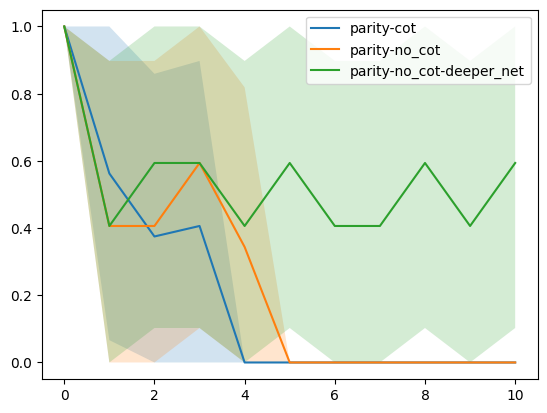

In [6]:
import matplotlib.pyplot as plt

for (row_i, row_data) in df.iterrows():
    mean_err = row_data["mean_error"].flatten()
    std_err = row_data["std_error"].flatten()
    context_len = len(mean_err)
    x_range = range(context_len)

    plt.plot(
        x_range,
        mean_err,
        label="-".join(row_data["run_name"].split("-")[:-8]),
    )
    plt.fill_between(
        x_range,
        np.clip(mean_err + std_err, a_min=0.0, a_max=1.0),
        np.clip(mean_err - std_err, a_min=0.0, a_max=1.0),
        alpha=0.2,
    )

plt.legend()    